# Lincoln Park & Lakeview Condo Sales

This notebook presents an exploratory data analysis of the sales of condominiums in the Lincoln Park and Lakeview zip codes of Chicago (60614 & 60657), with the ultimate goal being to create a predictive model of condo prices in the area based on location, square footage, bedroom count, etc.

Data is being pulled from a Postgres/PostGIS database containing 3 tables:
- `sales`: records of individual property sales
- `parcels`: information regarding zoned plots of land
- `characteristics`: qualities of each unit (e.g. bedroom count)

To see the table details, please reference `db/schema.sql` for the schema, and `src/fetch_*.py` for the scripts populating each table.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
sys.path.append("..")
from src.db import get_connection

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

## Load data

Each row represents an individual condo sale, joined to its parcel and characteristics. We have excluded sales labeled as parking-spaces and common-areas, as these sales are characterized under condo sales, but are not residential units and are not valuable for our analysis.

In [2]:
import numpy as np

QUERY = """
    select
        s.sale_price,
        s.sale_date,
        s.pin,
        p.zip_code,
        p.community_area,
        p.nbhd_code,
        c.class,
        c.year_built,
        c.sqft,
        c.bedrooms,
        c.full_baths,
        c.half_baths,
        c.building_sf,
        c.building_unit_count
    from sales s
    join parcels p on s.pin = p.pin
    join characteristics c on s.pin = c.pin
    where p.class in ('299', '399')
      and c.is_parking_space = false
      and c.is_common_area = false
"""

with get_connection() as conn:
    df = pd.read_sql(QUERY, conn)

df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_year"] = df["sale_date"].dt.year
df["log_price"] = np.log(df["sale_price"])

df.shape

(15402, 16)

In [3]:
df.head()

,sale_price,sale_date,pin,zip_code,community_area,nbhd_code,class,year_built,sqft,bedrooms,full_baths,half_baths,building_sf,building_unit_count,sale_year,log_price
0,830000.0,2025-11-26,13364230541001,60614,WEST TOWN,77030,299,2021,2686.0,4.0,2.0,1.0,6816.0,3,2025,13.629181
1,645640.0,2023-03-29,13364230541002,60614,WEST TOWN,77030,299,2021,NaN,3.0,2.0,NaN,6816.0,3,2023,13.377997
2,500000.0,2019-03-25,14194040301002,60657,LAKE VIEW,73081,299,2013,NaN,3.0,2.0,NaN,6676.0,3,2019,13.122363
3,510000.0,2022-01-14,14194040301003,60657,LAKE VIEW,73081,299,2011,1494.0,3.0,2.0,NaN,6676.0,3,2022,13.142166
4,686000.0,2023-06-06,14194040311005,60657,LAKE VIEW,73081,299,2005,1679.0,3.0,2.0,NaN,6411.0,3,2023,13.438633


## Missing values

Because Cook County did not begin collecting more detailed unit-level information until around 2021, many entries in our database are missing `sqft` and `bedrooms` data, which may create difficulties in our prediction model down the line. We will earmark this for now, and below is a visualization of the missing values in the graph.

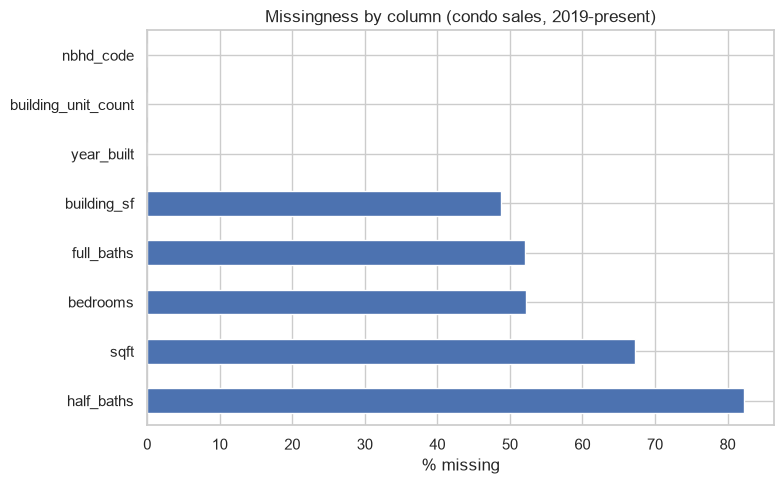

half_baths             82.288015
sqft                   67.283470
bedrooms               52.155564
full_baths             52.019218
building_sf            48.759901
year_built              0.000000
building_unit_count     0.000000
nbhd_code               0.000000
dtype: float64

In [4]:
cols_to_check = ["sqft", "bedrooms", "full_baths", "half_baths", "year_built", "building_sf", "building_unit_count", "nbhd_code"]
missing_pct = df[cols_to_check].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
missing_pct.plot(kind="barh", ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Missingness by column (condo sales, 2019-present)")
plt.tight_layout()
plt.show()

missing_pct

## Sales price distribution

Real estate prices are generally right-skewed, with luxury properties creating outliers that pull the mean up. This could warrant taking the logarithm of the values to create a more normally distributed dataset to consider.

count    1.540200e+04
mean     5.034486e+05
std      2.952087e+05
min      1.500000e+04
25%      2.850000e+05
50%      4.500000e+05
75%      6.500000e+05
max      5.800000e+06
Name: sale_price, dtype: float64

skew (raw): 2.23
skew (log): -0.25


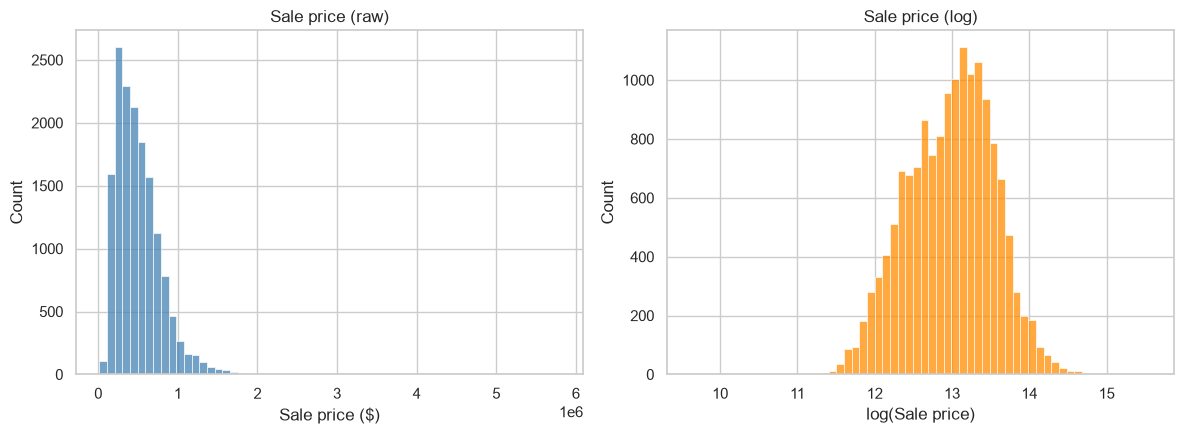

In [5]:
print(df["sale_price"].describe())
print()
print(f"skew (raw): {df['sale_price'].skew():.2f}")
print(f"skew (log): {df['log_price'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["sale_price"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Sale price (raw)")
axes[0].set_xlabel("Sale price ($)")

sns.histplot(df["log_price"], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Sale price (log)")
axes[1].set_xlabel("log(Sale price)")

plt.tight_layout()
plt.show()

As suspected, the distribution of `log_price` is roughly normal. This will make analysis simpler down the line.

## Price over time

Obviously the date will play a major role in real estate prices, so it is worth checking to see how prices have trended over time. This will also be helpful as a baseline when training our model, as we will likely be breaking the training data down based on date.

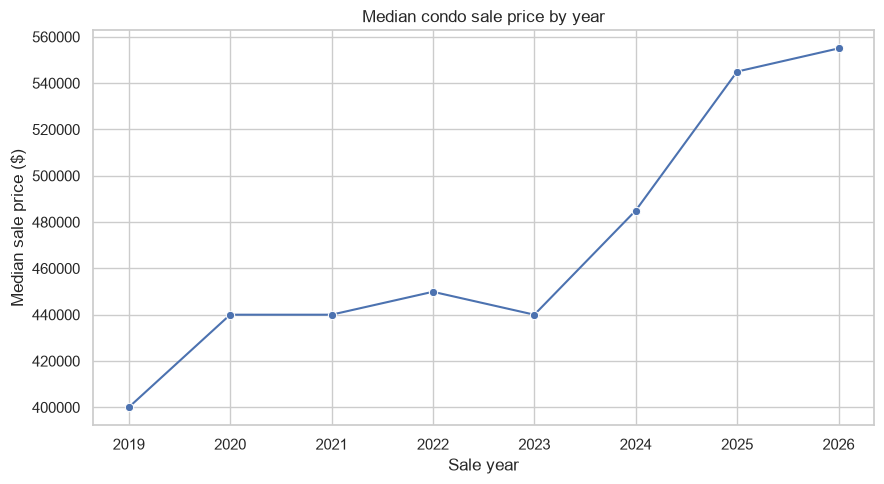

,median,count
sale_year,,
2019,400000.0,1907
2020,440000.0,2059
2021,440000.0,2930
2022,449900.0,2455
2023,440000.0,1750
2024,485000.0,1775
2025,545000.0,1807
2026,555000.0,719


In [6]:
yearly = df.groupby("sale_year")["sale_price"].agg(["median", "count"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=yearly.index, y=yearly["median"], marker="o", ax=ax)
ax.set_title("Median condo sale price by year")
ax.set_xlabel("Sale year")
ax.set_ylabel("Median sale price ($)")
plt.tight_layout()
plt.show()

yearly

## Price vs. square footage

While many rows are missing square footage data, the size of a unit is a major factor in cost.

After running this analysis, 14 rows were identified where the unit square footage was the same as the building square footage, resulting in 14 cheaply priced units with extremely high area, skewing the correlation.

After removing those incorrectly labeled rows, we see strong correlation between `log_price` and `sqft` of ~0.74.

dropping 14 rows where unit sqft >= building sqft (data bug, not a real unit size)
5025 of 15402 sales have usable sqft data (32.6%)


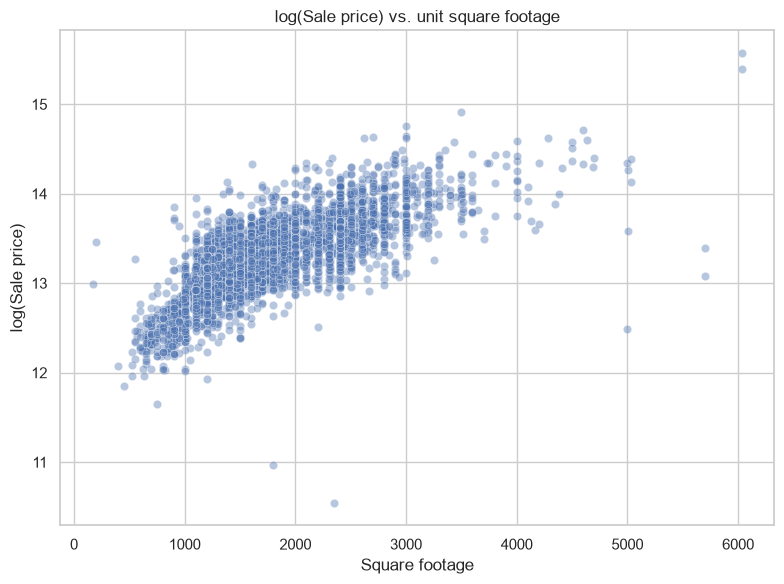

,sqft,log_price
sqft,1.00000,0.74224
log_price,0.74224,1.00000


In [7]:
with_sqft = df.dropna(subset=["sqft"])

bad_sqft = (with_sqft["building_unit_count"] > 1) & (with_sqft["sqft"] >= with_sqft["building_sf"])
print(f"dropping {bad_sqft.sum()} rows where unit sqft >= building sqft (data bug, not a real unit size)")
with_sqft = with_sqft[~bad_sqft]

print(f"{len(with_sqft)} of {len(df)} sales have usable sqft data ({len(with_sqft) / len(df):.1%})")

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=with_sqft, x="sqft", y="log_price", alpha=0.4, ax=ax)
ax.set_title("log(Sale price) vs. unit square footage")
ax.set_xlabel("Square footage")
ax.set_ylabel("log(Sale price)")
plt.tight_layout()
plt.show()

with_sqft[["sqft", "log_price"]].corr()

## Price by bedroom count

Using `log_price` here too to avoid outliers cluttering the box plots.

bedrooms
1.0     422
2.0    3514
3.0    2774
4.0     625
5.0      33
6.0       1
Name: count, dtype: int64


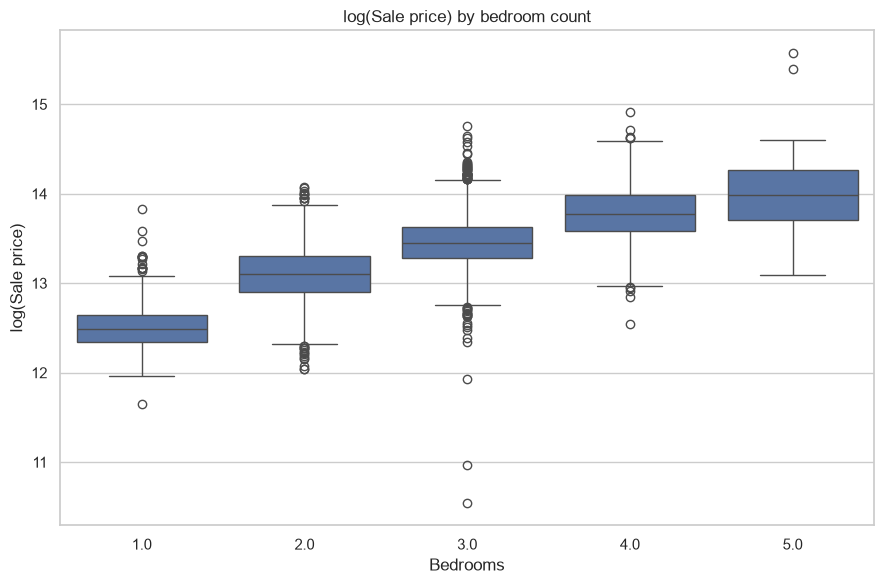

In [8]:
with_beds = df.dropna(subset=["bedrooms"])
bed_counts = with_beds["bedrooms"].value_counts().sort_index()
print(bed_counts)

# drop bedroom counts with too few sales to plot meaningfully
common_beds = bed_counts[bed_counts >= 20].index
plot_df = with_beds[with_beds["bedrooms"].isin(common_beds)]

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=plot_df, x="bedrooms", y="log_price", ax=ax)
ax.set_title("log(Sale price) by bedroom count")
ax.set_xlabel("Bedrooms")
ax.set_ylabel("log(Sale price)")
plt.tight_layout()
plt.show()

## Price by building age

Bucketed into decades built, since exact year-built vs. price is noisy at the individual-year level. Using `log_price` again, for the same outlier/compression reason as the bedroom count plot above.

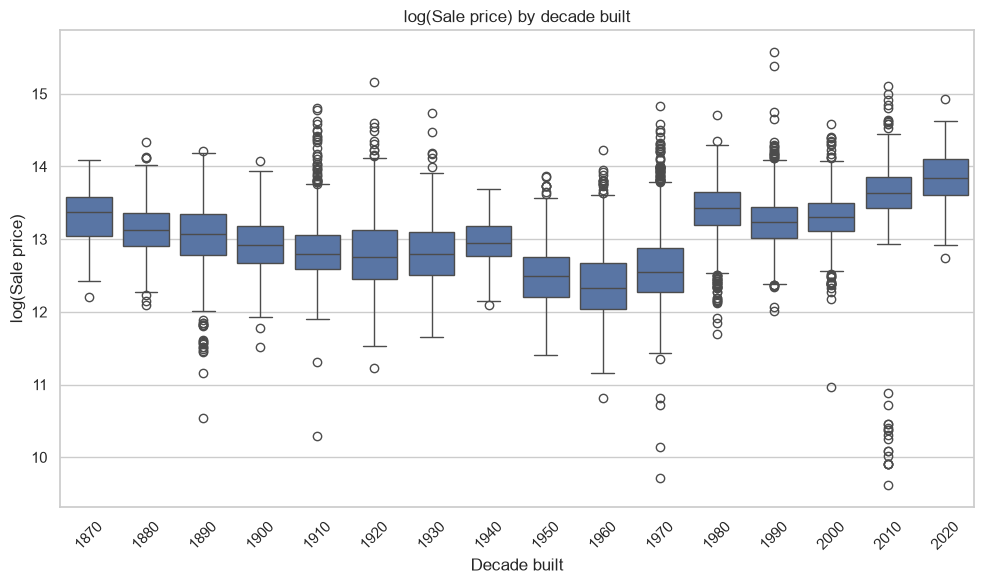

In [9]:
with_year = df.dropna(subset=["year_built"]).copy()
with_year["decade_built"] = (with_year["year_built"] // 10 * 10).astype(int)

decade_counts = with_year["decade_built"].value_counts()
common_decades = sorted(decade_counts[decade_counts >= 20].index)
plot_df = with_year[with_year["decade_built"].isin(common_decades)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=plot_df, x="decade_built", y="log_price", order=common_decades, ax=ax)
ax.set_title("log(Sale price) by decade built")
ax.set_xlabel("Decade built")
ax.set_ylabel("log(Sale price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation among numeric features

Using `log_price` and excluding the same bad-sqft rows as above, for consistency.

1795 of 15402 sales have all of ['log_price', 'sqft', 'bedrooms', 'full_baths', 'half_baths', 'year_built', 'building_sf'] present (11.7%)


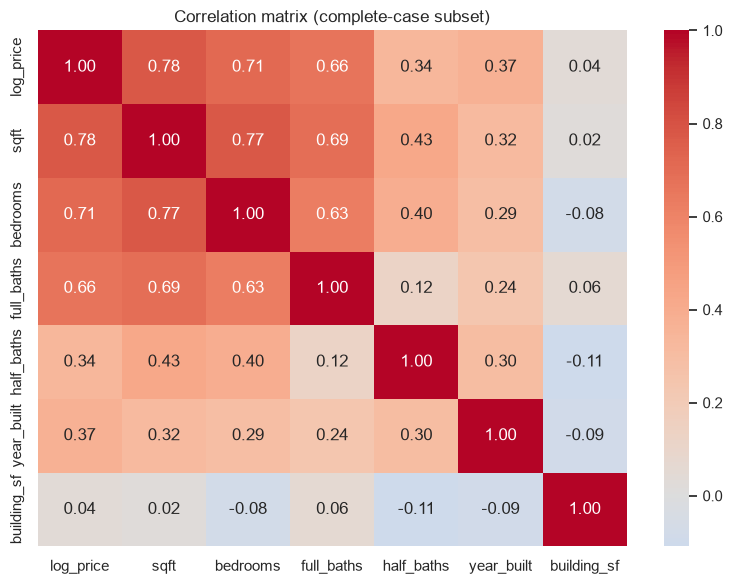

In [10]:
bad_sqft_full = (df["building_unit_count"] > 1) & (df["sqft"] >= df["building_sf"])
df_clean = df[~bad_sqft_full]

numeric_cols = ["log_price", "sqft", "bedrooms", "full_baths", "half_baths", "year_built", "building_sf"]
complete = df_clean.dropna(subset=numeric_cols)
print(f"{len(complete)} of {len(df)} sales have all of {numeric_cols} present ({len(complete) / len(df):.1%})")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(complete[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (complete-case subset)")
plt.tight_layout()
plt.show()